# ML supervisé de bout en bout

**Version atelier.** Les cellules marquées `# À VOUS` sont à compléter. Le corrigé sera déposé sur le serveur local en fin de séance.

**Togo AI Summer School 2026 (Filière F1)**
Mardi 25 août 2026 · M. ATARMLA Abdou-Raouf et Pr. PINDRA Nadjime

---

## Le cas

Une ONG suit 2 400 exploitations agricoles au Togo. Chaque campagne, une partie subit des
pertes post-récolte supérieures à 20 %. Le budget d'accompagnement est limité.

> **À qui adresser cet accompagnement, avant la récolte ?**

## Le plan

| Étape | Ce que l'on fait | Ce qui casse si on la saute |
|---|---|---|
| 1 | Cadrer la cible | on modélise autre chose que la question posée |
| 2 | Séparer train/test | le score mesure la mémoire, pas la généralisation |
| 3 | Poser une baseline | on célèbre un score qui ne vaut rien |
| 4 | Construire le pipeline | les transformations fuient d'un côté à l'autre |
| 5 | Évaluer | on croit un modèle qui ne détecte rien |
| 6 | Analyser les erreurs | on empile des modèles sans comprendre |
| 7 | Sauvegarder | le modèle part en production sans son seuil |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                             precision_recall_curve, roc_auc_score, roc_curve,
                             average_precision_score)

pd.set_option("display.width", 120) # Tells Pandas to change the maximum width of the console output to 120 characters before wrapping text to a new line.
# pd.set_option('display.max_columns', None) # Force Pandas to display all columns. Place before displaying your DataFrame
plt.rcParams["figure.figsize"] = (7, 3.4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

print("Environnement prêt")

Environnement prêt


In [2]:
df = pd.read_csv("data/recoltes_togo.csv")
print(df.shape)
df.head() #print the first 5 columns by default

(2400, 14)


,id_exploitation,region,culture_principale,type_sol,type_stockage,superficie_ha,distance_marche_km,pluviometrie_mm,age_exploitant,irrigation,formation_recue,delai_avant_vente_j,reclamation_appui_urgence,perte_elevee
0,EXP00001,Kara,manioc,sableux,magasin communautaire,2.63,12.0,671.0,62,0,0,1.0,0,0
1,EXP00002,Plateaux,sorgho,hydromorphe,case traditionnelle,0.61,46.8,1009.0,61,0,0,7.0,0,0
2,EXP00003,Kara,sorgho,ferrugineux,magasin communautaire,1.34,NaN,1075.0,53,0,1,21.0,0,0
3,EXP00004,Centrale,igname,ferrugineux,case traditionnelle,1.95,9.5,NaN,32,0,0,8.0,0,0
4,EXP00005,Maritime,sorgho,hydromorphe,case traditionnelle,2.67,23.1,534.0,38,0,0,22.0,1,1


---
# Étape 1 : Cadrer le problème

La demande de l'ONG telle qu'elle arrive : *« à qui adresser notre accompagnement ? »*.
Ce n'est pas encore un problème supervisé. Il le devient quand on écrit :

> Prédire `perte_elevee` ∈ {0, 1} à partir des seules informations disponibles
> **avant la récolte**.

La clause temporelle décide quelles colonnes ont le droit d'entrer dans le modèle.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_exploitation            2400 non-null   object 
 1   region                     2400 non-null   object 
 2   culture_principale         2400 non-null   object 
 3   type_sol                   2328 non-null   object 
 4   type_stockage              2400 non-null   object 
 5   superficie_ha              2400 non-null   float64
 6   distance_marche_km         2304 non-null   float64
 7   pluviometrie_mm            2232 non-null   float64
 8   age_exploitant             2400 non-null   int64  
 9   irrigation                 2400 non-null   int64  
 10  formation_recue            2400 non-null   int64  
 11  delai_avant_vente_j        2280 non-null   float64
 12  reclamation_appui_urgence  2400 non-null   int64  
 13  perte_elevee               2400 non-null   int64

Positifs : 338 sur 2400  (14.1%)


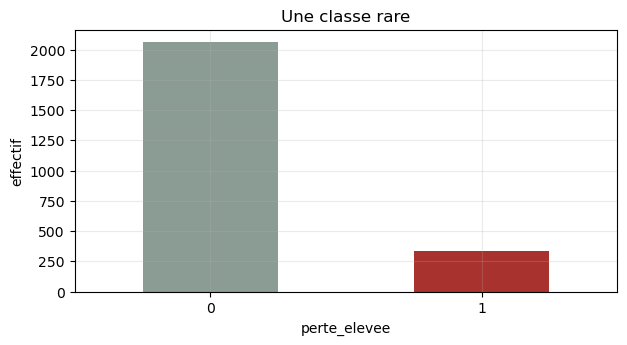

In [4]:
# Distribution de la cible
taux = df["perte_elevee"].mean()
print(f"Positifs : {df['perte_elevee'].sum()} sur {len(df)}  ({taux:.1%})")
df["perte_elevee"].value_counts().plot(kind="bar", color=["#8a9c93", "#a8322d"], rot=0)
plt.title("Une classe rare"); plt.ylabel("effectif"); plt.show()

In [5]:
# Valeurs manquantes
df.isna().sum()[lambda s: s > 0]

type_sol                72
distance_marche_km      96
pluviometrie_mm        168
delai_avant_vente_j    120
dtype: int64

### À noter

`type_sol`, `pluviometrie_mm`, `distance_marche_km` et `delai_avant_vente_j` ont des valeurs
manquantes. Nous ne les traitons pas maintenant : l'imputation ira **dans le pipeline**,
pour la raison expliquée à l'étape 4.

---
# Étape 2 : Séparer, avant tout le reste

L'erreur mesurée sur les données d'entraînement n'estime pas l'erreur de généralisation :
le modèle a été choisi en regardant ces données. Il faut des observations qu'il n'a
jamais vues.

In [6]:
X = df.drop(columns=["perte_elevee", "id_exploitation"])
y = df["perte_elevee"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=0
)

print(f"train : {len(X_train)}  ({y_train.mean():.1%} de positifs)")
print(f"test  : {len(X_test)}  ({y_test.mean():.1%} de positifs)")

train : 1800  (14.1% de positifs)
test  : 600  (14.0% de positifs)


`stratify=y` conserve la proportion de positifs des deux côtés. Sans lui, avec 14 % de
positifs, un tirage libre peut produire un test à 10 % ou à 18 % et rendre toute
comparaison impossible.

`random_state=0` rend le découpage reproductible. Ce n'est pas un confort : c'est ce qui
permet de discuter un résultat entre collègues.

## La colonne piège

Entraînons un premier modèle avec **toutes** les colonnes.

In [7]:
def construire_pipeline(X_ref, modele=None):
    # Pipeline complet : imputation, mise a l'echelle, encodage, classifieur.
    num = X_ref.select_dtypes(include="number").columns.tolist()
    cat = X_ref.select_dtypes(exclude="number").columns.tolist()
    prep = ColumnTransformer([
        ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                          ("sc",  StandardScaler())]), num),
        ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                          ("oh",  OneHotEncoder(handle_unknown="ignore"))]), cat),
    ])
    if modele is None:
        modele = LogisticRegression(max_iter=1000)
    return Pipeline([("prep", prep), ("clf", modele)])

In [8]:
avec_fuite = construire_pipeline(X_train).fit(X_train, y_train)
p_fuite = avec_fuite.predict_proba(X_test)[:, 1]

print(f"accuracy : {avec_fuite.score(X_test, y_test):.3f}")
print(f"AUC      : {roc_auc_score(y_test, p_fuite):.3f}")

accuracy : 0.943
AUC      : 0.959


**94 % d'accuracy sur des données jamais vues. On met en production ?**

Non. La colonne `reclamation_appui_urgence` enregistre une demande d'appui déposée
**après** la récolte, une fois la perte constatée. Elle est une conséquence de la cible,
pas une cause. En production, au moment où l'ONG doit décider, elle est vide pour tout
le monde.

> Une variable indisponible au moment de la prédiction est une fuite, même corrélée,
> même si elle améliore le score. Surtout si elle l'améliore beaucoup.

In [9]:
X = df.drop(columns=["perte_elevee", "id_exploitation", "reclamation_appui_urgence"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=0
)
print("Colonnes retenues :", list(X.columns))

Colonnes retenues : ['region', 'culture_principale', 'type_sol', 'type_stockage', 'superficie_ha', 'distance_marche_km', 'pluviometrie_mm', 'age_exploitant', 'irrigation', 'formation_recue', 'delai_avant_vente_j']


### Trois fuites plus discrètes

1. **Normaliser avant de séparer** : la moyenne et l'écart-type contiennent de
   l'information venue du test.
2. **Imputer avec la statistique globale** : même mécanisme.
3. **Dédupliquer après avoir séparé** : le même exploitant des deux côtés.

Aucune ne se voit dans le score. Elles le rendent seulement trop beau. Le `Pipeline` de
l'étape 4 les rend mécaniquement impossibles.

---
# Étape 3 : La baseline

Avant tout modèle, une référence : que donne un classifieur qui ne fait rien ?

In [10]:
baseline = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
acc_base = baseline.score(X_test, y_test)
print(f"Baseline : {acc_base:.3f}")

Baseline : 0.860


86 % de bonnes réponses. **Zéro exploitation accompagnée.**

Un modèle peut être excellent sur la métrique et totalement inutile pour la décision.

> Un modèle sans baseline n'a pas de score.

---
# Étape 4 : Le pipeline

Un seul objet contient la préparation et le modèle. C'est lui qu'on entraîne, qu'on
évalue en validation croisée et qu'on sauvegarde.

**Pourquoi c'est important :** l'imputation et la standardisation sont *apprises* sur le
train à chaque appel de `fit`, y compris à l'intérieur de chaque pli de validation
croisée. Les fuites 1 et 2 deviennent impossibles.

In [11]:
modele = construire_pipeline(X_train)
modele.fit(X_train, y_train)

acc = modele.score(X_test, y_test)
print(f"Baseline : {acc_base:.3f}")
print(f"Modèle   : {acc:.3f}")

Baseline : 0.860
Modèle   : 0.868


Huit millièmes de mieux qu'un modèle qui ne fait rien.

**Le modèle est-il mauvais, ou la métrique est-elle mauvaise ?**

## Le modèle ne prédit pas une classe

Il produit une probabilité, la fonction logistique appliquée à une combinaison linéaire
des variables :

$$P(Y=1 \mid x) = \sigma(\beta_0 + \beta^\top x) = \frac{1}{1 + e^{-(\beta_0 + \beta^\top x)}}$$

In [12]:
proba = modele.predict_proba(X_test)[:, 1]
print(np.round(proba[:8], 3))
print("\npredict() applique simplement le seuil 0,5 :")
print(modele.predict(X_test)[:8])

[0.294 0.078 0.01  0.156 0.018 0.009 0.136 0.092]

predict() applique simplement le seuil 0,5 :
[0 0 0 0 0 0 0 0]


---
# Étape 5 : Évaluer

## Pourquoi l'accuracy ment

Avec $\pi = P(Y=1)$ la prévalence,

$$\text{accuracy} = \pi \cdot \text{rappel} + (1-\pi) \cdot \text{spécificité}$$

Ici $\pi = 0{,}141$ : le second terme pèse six fois plus que le premier. Sur un phénomène
rare, l'accuracy mesure surtout la rareté.

In [13]:
pred = (proba >= 0.5).astype(int)
cm = confusion_matrix(y_test, pred)

print(pd.DataFrame(cm,
                   index=["réel 0", "réel 1"],
                   columns=["prédit 0", "prédit 1"]))

tn, fp, fn, tp = cm.ravel()
print(f"\nprécision : {tp/(tp+fp):.3f}")
print(f"rappel    : {tp/(tp+fn):.3f}   <-- {fn} exploitations à risque manquées sur {tp+fn}")

        prédit 0  prédit 1
réel 0       508         8
réel 1        71        13

précision : 0.619
rappel    : 0.155   <-- 71 exploitations à risque manquées sur 84


In [ ]:
print(classification_report(y_test, pred, digits=3,
                            target_names=["pas de perte", "perte élevée"]))

In [ ]:
# Pourquoi si peu de détections : la distribution des probabilités
bins = np.linspace(0, 1, 36)
plt.hist(proba[y_test == 0], bins=bins, color="#8a9c93", label="réel : pas de perte")
plt.hist(proba[y_test == 1], bins=bins, color="#a8322d", label="réel : perte élevée")
plt.axvline(0.5, color="black", ls="--")
plt.xlabel("probabilité prédite"); plt.ylabel("effectif"); plt.legend()
plt.title("Presque personne au-dessus de 0,5"); plt.show()

## Le seuil est une décision, pas un résultat

Pour une exploitation de probabilité $p$, comparons les coûts espérés :

$$\text{signaler} : (1-p)\,C_{FP} \qquad \text{ne pas signaler} : p\,C_{FN}$$

On a intérêt à signaler dès que

$$p\,C_{FN} > (1-p)\,C_{FP} \quad \Longleftrightarrow \quad p > \frac{C_{FP}}{C_{FP} + C_{FN}}$$

Si manquer une exploitation coûte dix fois une visite inutile, le seuil optimal vaut
$1/11 \approx 0{,}09$, et non 0,5.

In [ ]:
C_FN, C_FP = 10, 1

seuils = np.arange(0.02, 0.95, 0.005)
couts = []
for t in seuils:
    _, fp_t, fn_t, _ = confusion_matrix(y_test, (proba >= t).astype(int)).ravel()
    couts.append(C_FN * fn_t + C_FP * fp_t)
couts = np.array(couts)

t_opt = seuils[couts.argmin()]
print(f"seuil optimal : {t_opt:.3f}")
print(f"coût au seuil 0,50 : {couts[np.argmin(np.abs(seuils - 0.5))]}")
print(f"coût au seuil optimal : {couts.min()}")

plt.plot(seuils, couts, color="#1a6b45")
plt.plot(t_opt, couts.min(), "o", color="#a8322d")
plt.xlabel("seuil"); plt.ylabel("coût = 10·FN + FP")
plt.title("Le coût est divisé par plus de deux"); plt.show()

In [ ]:
cm_opt = confusion_matrix(y_test, (proba >= t_opt).astype(int))
print(pd.DataFrame(cm_opt, index=["réel 0", "réel 1"], columns=["prédit 0", "prédit 1"]))

_, fp2, fn2, tp2 = cm_opt.ravel()
print(f"\nrappel au seuil optimal : {tp2/(tp2+fn2):.3f}")
print(f"visites inutiles        : {fp2}")

In [ ]:
# Précision et rappel varient en sens inverse
prec, rap, thr = precision_recall_curve(y_test, proba)
plt.plot(thr, prec[:-1], label="précision", color="#2c5f7c")
plt.plot(thr, rap[:-1], label="rappel", color="#a8322d")
plt.axvline(0.5, ls="--", color="#8a9c93")
plt.axvline(t_opt, ls="--", color="#1a6b45")
plt.xlim(0, 0.8); plt.xlabel("seuil"); plt.legend()
plt.title("Aucun seuil ne maximise les deux"); plt.show()

## Un score est une variable aléatoire

Le score dépend du découpage. La validation croisée en donne la dispersion.

In [ ]:
cv = cross_val_score(construire_pipeline(X), X, y,
                     cv=StratifiedKFold(5),
                     scoring="average_precision")
print(np.round(cv, 3))
print(f"moyenne {cv.mean():.3f}   écart-type {cv.std():.3f}")

Un écart de 0,02 entre deux modèles n'est pas une différence.

---
# Atelier : la contrainte opérationnelle

> L'ONG peut accompagner **150 exploitations** cette campagne. Votre modèle doit lui dire
> lesquelles. **Justifiez votre seuil.**

Le seuil optimal théorique (0,075) sélectionne beaucoup trop d'exploitations pour le
budget réel. Il faut trouver le seuil qui remplit exactement les 150 places, puis dire
honnêtement ce que l'ONG y gagne et ce qu'elle y perd.

In [ ]:
# À VOUS
#
# Indications : voir la cellule markdown ci-dessus.
# Objets déjà disponibles : proba, y_test, X_test, seuils,
# modele, construire_pipeline, C_FN, C_FP.


In [ ]:
# À VOUS
#
# Indications : voir la cellule markdown ci-dessus.
# Objets déjà disponibles : proba, y_test, X_test, seuils,
# modele, construire_pipeline, C_FN, C_FP.


### La recommandation à l'ONG

À rédiger en deux phrases, en s'adressant à l'ONG et non au modèle. Un exemple de ce qui
est attendu :

> Avec un budget de 150 visites, nous recommandons de cibler les exploitations dont la
> probabilité de perte élevée dépasse 0,195. Ce ciblage permet d'atteindre environ 60 %
> des exploitations réellement à risque, contre 15 % si l'on s'en tenait au seuil par
> défaut du modèle ; il reste que deux tiers des visites porteront sur des exploitations
> qui n'auraient pas subi de perte.

---
# Étape 6 : Analyser les erreurs

Dix minutes passées à regarder des erreurs valent mieux que dix modèles de plus.

In [ ]:
# À VOUS
#
# Indications : voir la cellule markdown ci-dessus.
# Objets déjà disponibles : proba, y_test, X_test, seuils,
# modele, construire_pipeline, C_FN, C_FP.


In [ ]:
# À VOUS
#
# Indications : voir la cellule markdown ci-dessus.
# Objets déjà disponibles : proba, y_test, X_test, seuils,
# modele, construire_pipeline, C_FN, C_FP.


## Ce que le modèle a retenu

Un coefficient de la régression logistique se lit comme un logarithme de rapport de cotes :
augmenter $x_j$ d'une unité multiplie la cote $p/(1-p)$ par $e^{\beta_j}$.

In [ ]:
prep_ajuste = modele.named_steps["prep"]
noms = (X.select_dtypes(include="number").columns.tolist()
        + list(prep_ajuste.named_transformers_["cat"]
               .named_steps["oh"]
               .get_feature_names_out(X.select_dtypes(exclude="number").columns)))

coefs = pd.Series(modele.named_steps["clf"].coef_[0], index=noms)
coefs = coefs.reindex(coefs.abs().sort_values(ascending=False).index)

tableau = pd.DataFrame({"coefficient": coefs.round(3),
                        "rapport de cotes": np.exp(coefs).round(2)})
tableau.head(12)

---
# Étape 7 : Sauvegarder

Un pipeline sauvegardé sans son seuil est incomplet. C'est l'erreur classique au moment
de la mise en production : le modèle est déployé, et `predict` applique silencieusement 0,5.

In [ ]:
import joblib

artefact = {
    "modele": modele,
    "seuil": float(t_budget),
    "colonnes": list(X.columns),
    "metriques_test": {
        "accuracy": float(acc),
        "auc": float(roc_auc_score(y_test, proba)),
        "rappel_au_seuil": float(tp_b / (tp_b + fn_b)),
    },
}
joblib.dump(artefact, "modele_pertes.joblib")
print("Sauvegardé.")

recharge = joblib.load("modele_pertes.joblib")
p = recharge["modele"].predict_proba(X_test.head(5))[:, 1]
print("Décisions :", (p >= recharge["seuil"]).astype(int))

---
# Extensions

À traiter si vous avez terminé avant la fin de l'atelier. Ces cellules ne sont pas
présentées au tableau.

### Extension 1 : le seuil pèse-t-il plus que le modèle ?

Comparez la régression logistique à une forêt aléatoire, en optimisant le seuil des deux.
La différence entre modèles est-elle plus grande que celle entre seuils ?

In [ ]:
# À VOUS
#
# Indications : voir la cellule markdown ci-dessus.
# Objets déjà disponibles : proba, y_test, X_test, seuils,
# modele, construire_pipeline, C_FN, C_FP.


### Extension 2 : sensibilité au ratio de coût

Le ratio de 10 a été posé par hypothèse. Recalculez le seuil optimal pour un ratio de 3,
puis de 20. De combien la recommandation change-t-elle ?

In [ ]:
# À VOUS
#
# Indications : voir la cellule markdown ci-dessus.
# Objets déjà disponibles : proba, y_test, X_test, seuils,
# modele, construire_pipeline, C_FN, C_FP.


### Extension 3 : pondération des classes

`class_weight="balanced"` donne à chaque positif un poids $n/(2 n_1)$ dans la fonction de
coût. Comparez le rappel obtenu au seuil 0,5 avec et sans pondération, puis l'AUC.
Que constatez-vous sur le pouvoir discriminant ?

In [ ]:
# À VOUS
#
# Indications : voir la cellule markdown ci-dessus.
# Objets déjà disponibles : proba, y_test, X_test, seuils,
# modele, construire_pipeline, C_FN, C_FP.


---
## Les trois phrases à emporter

1. Un score se vérifie avant de se célébrer.
2. Un score n'existe que relativement à une baseline.
3. Le modèle produit une probabilité. C'est l'humain qui décide.

## Pour la suite de la semaine

- **Bloc B, cet après-midi** : le même pipeline sur d'autres données agricoles (à confirmer)
- **Mercredi** : `modele_pertes.joblib` exposé en API (à confirmer)
- **Jeudi** : surveillance de ce score en production
- **Vendredi** : le protocole d'évaluation comme critère de la restitution

**Avant de partir :** pensez à un jeu de données de votre travail. Quelle colonne serait
une fuite ?